Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/fmsg_sweep_heatmaps.png
Saved: /Users/nandan/Desktop/CTCs/IBM/fmsg_sweep_heatmaps.pdf


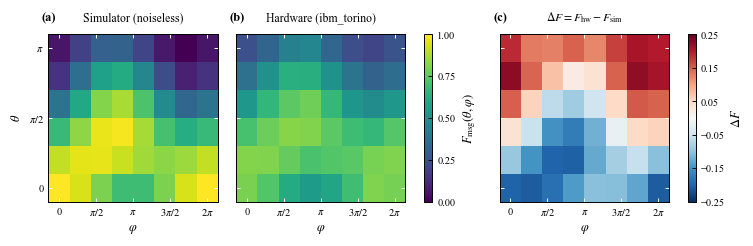

In [2]:
"""
PRX 3-panel heatmap figure: F_msg(theta, phi) — simulator vs hardware vs difference.

Tweakables are grouped at the top.  Run:
    python fmsg_sweep_heatmaps.py

Outputs:
    fmsg_sweep_heatmaps.png  (600 dpi)
    fmsg_sweep_heatmaps.pdf  (vector, for LaTeX)

------------------------------------------------------------------
FONT NOTES (project standard)
------------------------------------------------------------------
This script tries to use real Times New Roman if available on your
system; if not, it falls back to STIX Two Text (a Times look-alike
that ships with matplotlib).  Either way, the output looks like
Times — no DejaVu Serif silent fallback.

If you want to force real Times New Roman:
  - macOS / Windows: usually already installed; should be detected.
  - Linux: `sudo apt install msttcorefonts-installer ttf-mscorefonts-installer`
           then `rm -rf ~/.cache/matplotlib` to clear the font cache.
"""
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import FuncFormatter, FixedLocator

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_JSON   = "hw_sweep_results.json"
OUT_BASE     = "/Users/nandan/Desktop/CTCs/IBM/fmsg_sweep_heatmaps"   # .png + .pdf appended

FIGSIZE_IN   = (7.0, 2.7)         # PRX double-column = 7.0 in wide
CMAP_SEQ     = "viridis"          # sequential cmap for F_sim, F_hw (panels a, b)
CMAP_DIV     = "RdBu_r"           # diverging cmap for delta_F (panel c)

# Subtitle text above each panel
SUB_A = "Simulator (noiseless)"
SUB_B = "Hardware (ibm_torino)"     # auto-replaced from data if available
SUB_C = r"$\Delta F = F_{\mathrm{hw}} - F_{\mathrm{sim}}$"

# ============================================================
# Font selection: real Times if available, else STIX Two Text
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

# ============================================================
# PRX-style rcParams
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           8,
    "axes.labelsize":      9,
    "axes.titlesize":      9,
    "xtick.labelsize":     7.5,
    "ytick.labelsize":     7.5,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "axes.spines.top":     True,
    "axes.spines.right":   True,
    "pdf.fonttype":        42,    # editable text in PDF
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
with open(INPUT_JSON) as f:
    data = json.load(f)

meta   = data["metadata"]
thetas = np.asarray(meta["thetas"])
phis   = np.asarray(meta["phis"])
F_sim  = np.asarray(data["F_sim"])     # shape (n_theta, n_phi)
F_hw   = np.asarray(data["F_hw"])
dF     = np.asarray(data["delta_F"])

# Use backend name from data if present
backend_name = meta.get("backend", "hardware")
SUB_B = f"Hardware ({backend_name})"

# ============================================================
# Helpers
# ============================================================
def edges_from_centers(c):
    """Convert N pixel centers to N+1 pixel edges (for pcolormesh)."""
    c = np.asarray(c, dtype=float)
    step = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = (c[:-1] + c[1:]) / 2
    e[0]    = c[0]  - step[0]  / 2
    e[-1]   = c[-1] + step[-1] / 2
    return e

def pi_formatter(val, _pos):
    """Format radian tick labels as π fractions."""
    if np.isclose(val, 0):           return "0"
    if np.isclose(val, np.pi/2):     return r"$\pi/2$"
    if np.isclose(val, np.pi):       return r"$\pi$"
    if np.isclose(val, 3*np.pi/2):   return r"$3\pi/2$"
    if np.isclose(val, 2*np.pi):     return r"$2\pi$"
    return f"{val/np.pi:.2g}$\\pi$"

phi_e   = edges_from_centers(phis)
theta_e = edges_from_centers(thetas)

# Symmetric ΔF range, snapped up to a clean number
raw_max  = np.max(np.abs(dF))
vmax_dF  = np.ceil(raw_max * 20) / 20    # snap to nearest 0.05

# ============================================================
# Figure layout
# ============================================================
fig = plt.figure(figsize=FIGSIZE_IN)
gs = fig.add_gridspec(
    nrows=1, ncols=6,
    width_ratios=[1.0, 1.0, 0.05, 0.18, 1.0, 0.05],   # col 3 = spacer
    wspace=0.20,
    left=0.06, right=0.985, top=0.80, bottom=0.18,
)
ax_a   = fig.add_subplot(gs[0, 0])
ax_b   = fig.add_subplot(gs[0, 1], sharey=ax_a)
cax_ab = fig.add_subplot(gs[0, 2])
ax_c   = fig.add_subplot(gs[0, 4], sharey=ax_a)
cax_c  = fig.add_subplot(gs[0, 5])

# ============================================================
# Draw heatmaps
# ============================================================
im_a = ax_a.pcolormesh(phi_e, theta_e, F_sim, cmap=CMAP_SEQ,
                       vmin=0.0, vmax=1.0, shading="auto", rasterized=True)
im_b = ax_b.pcolormesh(phi_e, theta_e, F_hw,  cmap=CMAP_SEQ,
                       vmin=0.0, vmax=1.0, shading="auto", rasterized=True)
im_c = ax_c.pcolormesh(phi_e, theta_e, dF,    cmap=CMAP_DIV,
                       vmin=-vmax_dF, vmax=+vmax_dF, shading="auto", rasterized=True)

# ============================================================
# Axis ticks (radian labels)
# ============================================================
phi_ticks   = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
theta_ticks = [0, np.pi/2, np.pi]

for ax in (ax_a, ax_b, ax_c):
    ax.set_xlim(phi_e[0], phi_e[-1])
    ax.set_ylim(theta_e[0], theta_e[-1])
    ax.xaxis.set_major_locator(FixedLocator(phi_ticks))
    ax.yaxis.set_major_locator(FixedLocator(theta_ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(pi_formatter))
    ax.set_xlabel(r"$\varphi$")
    ax.tick_params(which="both", color="white", top=True, right=True)
    for s in ax.spines.values():
        s.set_color("black")
        s.set_linewidth(0.7)

ax_a.set_ylabel(r"$\theta$")
plt.setp(ax_b.get_yticklabels(), visible=False)
plt.setp(ax_c.get_yticklabels(), visible=False)

# ============================================================
# Panel labels and sub-titles
# ============================================================
panels = [("(a)", ax_a, SUB_A),
          ("(b)", ax_b, SUB_B),
          ("(c)", ax_c, SUB_C)]
for letter, ax, sub in panels:
    ax.text(-0.04, 1.06, letter, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9, fontweight="bold")
    ax.text(0.5, 1.06, sub, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8.5)

# ============================================================
# Colorbars
# ============================================================
cb_ab = fig.colorbar(im_b, cax=cax_ab)
cb_ab.set_label(r"$F_{\mathrm{msg}}(\theta,\varphi)$", labelpad=4)
cb_ab.outline.set_linewidth(0.7)
cb_ab.ax.tick_params(width=0.7, length=3, direction="in", labelsize=7.5)
cb_ab.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])

cb_c = fig.colorbar(im_c, cax=cax_c)
cb_c.set_label(r"$\Delta F$", labelpad=4)
cb_c.outline.set_linewidth(0.7)
cb_c.ax.tick_params(width=0.7, length=3, direction="in", labelsize=7.5)
cb_c.set_ticks(np.arange(-vmax_dF, vmax_dF + 1e-9, 0.1))

# ============================================================
# Save
# ============================================================
fig.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")